## 1. Transcripción Automatizada del Audio (ASR)

En esta primera etapa procesamos las retransmisiones en formato audio (`.mp3`) para extraer el texto transcrito junto con sus marcas de tiempo exactas (`start` y `end`).

**Puntos clave del procesamiento:**
* **Modelo:** Se utiliza `faster-whisper` con el *checkpoint* `large-v3` sobre GPU (`cuda` en `float16`) para optimizar la velocidad de inferencia sin perder precisión léxica.
* **Control de alucinaciones:** Se fija `condition_on_previous_text=False` para evitar que el modelo entre en bucles de repetición provocados por el ruido de fondo, cánticos o murmullos del estadio.
* **Búsqueda:** Se emplea `beam_size=5` para priorizar la coherencia global del discurso de los comentaristas.
* **Caché:** Se comprueba la existencia de transcripciones previas para evitar reprocesar archivos JSON ya generados.

In [8]:
import os
import json
import time
from faster_whisper import WhisperModel

# 1. Configuración de directorios
audio_dir = os.path.join("..", "data", "transcripts")
transcript_dir = os.path.join("..", "data", "transcripts")
os.makedirs(transcript_dir, exist_ok=True)

# 2. Carga del modelo)
# device="cuda" y compute_type="float16"
model = WhisperModel("large-v3", device="cuda", compute_type="float16")
print("Modelo cargado correctamente. Iniciando procesamiento...\n")

# 3. Bucle de transcripción
for file in os.listdir(audio_dir):
    if file.endswith(".mp3"):
        audio_path = os.path.join(audio_dir, file)
        json_file = f"{os.path.splitext(file)[0]}.json"
        json_path = os.path.join(transcript_dir, json_file)
        
        # Sistema de caché: evitamos reprocesar si el JSON ya existe
        if os.path.exists(json_path):
            print(f"Saltando '{file}', ya existe su transcripción.")
            continue
            
        print(f"Transcribiendo: {file}...")
        start_time = time.time()
        
        # beam_size=5 mejora la coherencia del texto a costa de un poco de velocidad
        # condition_on_previous_text=False evita que el modelo entre en bucles de alucinación con el ruido del estadio
        segments, info = model.transcribe(
            audio_path, 
            language="es",
            beam_size=5,
            condition_on_previous_text=False 
        )
        
        print(f"Detectado idioma '{info.language}' con probabilidad {info.language_probability:.2f}")
        
        # faster-whisper devuelve un generador, iteramos para extraer los datos
        transcription_data = []
        for segment in segments:
            transcription_data.append({
                "id": segment.id,
                "start": segment.start,
                "end": segment.end,
                "text": segment.text.strip()
            })
            
        # Guardado estructurado en JSON
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(transcription_data, f, ensure_ascii=False, indent=4)
            
        elapsed_time = time.time() - start_time
        print(f"✔ Transcripción guardada en {json_path} (Tiempo: {elapsed_time:.2f} segundos)\n")

Modelo cargado correctamente. Iniciando procesamiento...

Transcribiendo: España - Arabia Saudí ｜ Grupo H ｜ Fase de grupos.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Arabia Saudí ｜ Grupo H ｜ Fase de grupos.json (Tiempo: 354.19 segundos)

Transcribiendo: España - Argentina ｜ Mundial FIFA 2026.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Argentina ｜ Mundial FIFA 2026.json (Tiempo: 695.24 segundos)

Transcribiendo: España - Austria ｜ Dieciseisavos de final.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Austria ｜ Dieciseisavos de final.json (Tiempo: 397.94 segundos)

Transcribiendo: España - Bélgica ｜ Cuartos de final.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Bélgica ｜ Cuartos de final.json (Tiempo: 375.07 segundos)

Transcribiendo: España

## 2. Filtrado y Normalización Temporal de las Transcripciones

Los archivos de audio brutos contienen pausas, publicidad previa, tiempo de descanso o análisis post-partido. Para analizar con precisión la dinámica temporal del juego, este bloque filtra y estructura los datos según los límites efectivos del encuentro.

**Puntos clave del procesamiento:**
* **Metadatos temporales:** Se leen los intervalos de tiempo reales (`1P`, `2P`, `TE`, `PEN`) almacenados en `matches metadata.json`. Han sido generados a través de gemini aportandole los json originales, se ha hecho comprobación manual posterior
* **Emparejamiento flexible:** Se tokenizan las claves de los partidos (ej. `espana_francia`) para asociar dinámicamente cada archivo independientemente del orden de los equipos en el nombre del `.mp3`.
* **Cálculo de tiempo relativo ($t_{rel}$):** Además de conservar los *timestamps* absolutos del archivo, se calcula el tiempo en segundos desde el inicio exacto de cada parte ($t_{rel} = t_{abs} - t_{inicio\_periodo}$). Esto facilita el alineamiento minuto a minuto para el modelado posterior de series temporales.
* **Almacenamiento estructurado:** Los datos limpios se exportan en formato JSON a la carpeta `data/clean_transcripts/`.

In [15]:
import re
import unicodedata

# 1. Configuración de directorios
data_dir = os.path.join("..", "data")
transcripts_dir = os.path.join(data_dir, "transcripts")
clean_dir = os.path.join(data_dir, "clean_transcripts")
os.makedirs(clean_dir, exist_ok=True)

# Ruta del archivo de metadatos
metadata_path = os.path.join(transcripts_dir, "matches metadata.json")

# 2. Carga dinámica de metadatos desde el archivo JSON
with open(metadata_path, "r", encoding="utf-8") as f:
    match_metadata = json.load(f)

# Función para normalizar texto (quita acentos y caracteres especiales)
def normalize_string(text):
    text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8")
    return re.sub(r'[^a-zA-Z0-9\s_]', '', text).lower()

# Listar todos los JSON de transcripciones brutas
raw_json_files = [
    f for f in os.listdir(transcripts_dir) 
    if f.endswith(".json") and f != os.path.basename(metadata_path)
]

# 3. Procesamiento y filtrado de las transcripciones
for match_key, intervals in match_metadata.items():
    # Extraemos las palabras clave dividiendo por '_' (ej. ['espana', 'francia'])
    key_terms = [normalize_string(term) for term in match_key.split('_') if term]
    
    # Buscamos un archivo que contenga TODAS las palabras clave de la llave
    matching_file = None
    for f in raw_json_files:
        norm_file_name = normalize_string(f)
        if all(term in norm_file_name for term in key_terms):
            matching_file = f
            break
    
    if not matching_file:
        print(f"No se encontró archivo transcrito para la clave: '{match_key}'")
        continue

    raw_file_path = os.path.join(transcripts_dir, matching_file)
    with open(raw_file_path, "r", encoding="utf-8") as f:
        segments = json.load(f)

    clean_segments = []
    
    for seg in segments:
        seg_start = seg["start"]
        seg_end = seg["end"]
        
        # Evaluar en qué periodo del partido (1P, 2P, TE, PEN) encaja el segmento
        for period, times in intervals.items():
            if times is not None:
                if seg_start >= times["start"] and seg_end <= times["end"]:
                    clean_segments.append({
                        "id": seg["id"],
                        "period": period,
                        "start": seg_start,
                        "end": seg_end,
                        "relative_start": round(seg_start - times["start"], 2),
                        "relative_end": round(seg_end - times["start"], 2),
                        "text": seg["text"]
                    })
                    break 

    # Guardar la transcripción limpia
    output_filename = f"{match_key}_clean.json"
    output_path = os.path.join(clean_dir, output_filename)
    
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(clean_segments, f, ensure_ascii=False, indent=4)

    print(f"Procesado: {match_key} -> {len(clean_segments)} segmentos guardados en {output_filename}")

Procesado: espana_arabia_saudi -> 2253 segmentos guardados en espana_arabia_saudi_clean.json
Procesado: espana_argentina -> 3827 segmentos guardados en espana_argentina_clean.json
Procesado: espana_austria -> 2241 segmentos guardados en espana_austria_clean.json
Procesado: espana_belgica -> 2466 segmentos guardados en espana_belgica_clean.json
Procesado: espana_cabo_verde -> 2469 segmentos guardados en espana_cabo_verde_clean.json
Procesado: espana_francia -> 2639 segmentos guardados en espana_francia_clean.json
Procesado: espana_portugal -> 2524 segmentos guardados en espana_portugal_clean.json
Procesado: espana_uruguay -> 2618 segmentos guardados en espana_uruguay_clean.json


## 3. Reconocimiento de Entidades (NER) y Análisis de Sentimiento por Segmento

En esta etapa enriquecemos el conjunto de transcripciones filtradas extrayendo dos dimensiones fundamentales: las menciones a los integrantes de la Selección Española y la polaridad emocional del discurso de los comentaristas en cada instante.

**Puntos clave de la metodología:**
* **Normalización de Entidades y Diccionario de Alias:** Tras auditar las transcripciones generadas por Whisper, se detectó un número significativo de desviaciones fonéticas y errores ortográficos en los nombres propios (ej. *"Ollarzabal"*[cite: 4], *"Kubarsin"*[cite: 4], *"la Min"*[cite: 4] o *"Alevaina"*[cite: 4]). Para resolver esto, **se ha utilizado Gemini para mapear la plantilla oficial de la RFEF y detectar automáticamente las posibles variantes transcritas**. Con ello se ha construido un diccionario canónico que vincula alias y aberraciones fonéticas con la identidad oficial de cada futbolista.
* **Extracción de Entidades con Regex Boundings:** Se implementa un algoritmo de emparejamiento por límites de palabra (`\b`) ordenado por longitud descendente de alias. Esto garantiza que términos complejos (ej. *"Lamine Yamal"*) se procesen antes que sus partes (*"Lamine"*) y evita falsos positivos por subcadenas en el texto.
* **Análisis de Sentimiento Transformer:** Se aplica el modelo `pysentimiento` (RoBERTa preentrenado en español) a cada segmento para obtener las probabilidades de las clases Positivo (`POS`), Negativo (`NEG`) y Neutro (`NEU`).
* **Indicador de Polaridad Neta ($S_t$):** Se define un índice continuo $S_t = P(\text{POS})_t - P(\text{NEG})_t \in [-1, 1]$ que cuantifica la inclinación emocional de la narración en cada tramo del partido.
* **Consolidación de Datos:** Los resultados procesados de todos los encuentros se integran en un conjunto de datos consolidado y se exportan en formatos Parquet (`data/processed/sentiment_ner_dataset.parquet`) y CSV para las etapas de modelado de grafos y series temporales.

In [18]:
import pandas as pd
import spacy
from pysentimiento import create_analyzer

# 1. Configuración de directorios
data_dir = os.path.join("..", "data")
clean_dir = os.path.join(data_dir, "clean_transcripts")
processed_dir = os.path.join(data_dir, "processed")
os.makedirs(processed_dir, exist_ok=True)

# 2. Carga del CSV de jugadores para construir el mapeo oficial
df_players = pd.read_csv(os.path.join(data_dir, "jugadores_esp.csv"))

# Diccionario de alias con variantes oficiales y errores comunes detectados de Whisper
PLAYER_ALIASES = {
    "Unai Simón": ["unai simon", "unai simón", "unai", "simon", "simón", "unesimon", "unesimón"],
    "David Raya": ["david raya", "raya"],
    "Joan García": ["joan garcia", "joan garcía"],
    "Marc Pubill": ["marc pubill", "pubill"],
    "Álex Grimaldo": ["alex grimaldo", "álex grimaldo", "grimaldo"],
    "Eric García": ["eric garcia", "eric garcía"],
    "Marcos Llorente": ["marcos llorente", "llorente"],
    "Pedro Porro": ["pedro porro", "porro"],
    "Aymeric Laporte": ["aymeric laporte", "laporte", "balapor"],
    "Pau Cubarsí": ["pau cubarsi", "pau cubarsí", "cubarsi", "cubarsí", "cubarsin", "cubarsín", "kubarsin", "kubarsy", "kubarsik", "pauco barcis"],
    "Marc Cucurella": ["marc cucurella", "cucurella", "kukureya", "cucurilla", "curella"],
    "Mikel Merino": ["mikel merino", "merino"],
    "Fabián Ruiz": ["fabian ruiz", "fabián ruiz", "fabian", "fabián", "fabiana"],
    "Gavi": ["gavi"],
    "Dani Olmo": ["dani olmo", "daniel olmo", "olmo", "danielmo"],
    "Álex Baena": ["alex baena", "álex baena", "baena", "sbaena", "alevaina", "vales baena"],
    "Rodri": ["rodri", "rodrigo hernandez", "rodrigo hernández"],
    "Martín Zubimendi": ["martin zubimendi", "martín zubimendi", "zubimendi", "zubi", "subil"],
    "Ferran Torres": ["ferran torres", "ferran", "ferrán"],
    "Yeremy Pino": ["yeremy pino", "yeremy"],
    "Nico Williams": ["nico williams", "williams", "nico"],
    "Lamine Yamal": ["lamine yamal", "lamine", "yamal", "lamin", "la min", "la mim", "mini"],
    "Pedri": ["pedri", "pedri gonzalez"],
    "Mikel Oyarzabal": ["mikel oyarzabal", "oyarzabal", "ollarzabal", "arzabal", "jarzabal", "ollantrabal", "yarzabal"],
    "Víctor Muñoz": ["victor muñoz", "víctor muñoz", "victor munoz"],
    "Borja Iglesias": ["borja iglesias", "iglesias", "panda"]
}

# Invertir el diccionario para una búsqueda rápida: alias_normalizado -> Nombre Oficial
ALIAS_TO_CANONICAL = {}
for canonical_name, aliases in PLAYER_ALIASES.items():
    for alias in aliases:
        ALIAS_TO_CANONICAL[alias.lower()] = canonical_name

# Función auxiliar para quitar acentos
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFD', input_str)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

def extract_players_from_text(text):
    """Detecta menciones a jugadores considerando errores de transcripción."""
    text_clean = remove_accents(text.lower())
    detected_players = set()
    
    # Ordenar alias por longitud descendente para emparejar 'lamine yamal' antes que 'lamine'
    sorted_aliases = sorted(ALIAS_TO_CANONICAL.keys(), key=len, reverse=True)
    
    for alias in sorted_aliases:
        alias_clean = remove_accents(alias)
        # Búsqueda por palabra exacta mediante Regex
        pattern = r'\b' + re.escape(alias_clean) + r'\b'
        if re.search(pattern, text_clean):
            canonical_name = ALIAS_TO_CANONICAL[alias]
            detected_players.add(canonical_name)
            
    return list(detected_players)

# 3. Carga de modelos de NLP y Sentimiento
print("Cargando modelo de Sentimiento (pysentimiento)...")
sentiment_analyzer = create_analyzer(task="sentiment", lang="es")

# 4. Procesamiento de todos los JSON limpios
clean_files = [f for f in os.listdir(clean_dir) if f.endswith("_clean.json")]
all_rows = []

for file_name in clean_files:
    match_id = file_name.replace("_clean.json", "")
    file_path = os.path.join(clean_dir, file_name)
    
    with open(file_path, "r", encoding="utf-8") as f:
        segments = json.load(f)
        
    print(f"Procesando NLP y Sentimiento para: {match_id} ({len(segments)} segmentos)...")
    
    for seg in segments:
        text = seg["text"]
        if not text:
            continue
            
        # Analizar sentimiento
        sent_res = sentiment_analyzer.predict(text)
        pos_score = sent_res.probas["POS"]
        neg_score = sent_res.probas["NEG"]
        neu_score = sent_res.probas["NEU"]
        
        # Extraer jugadores con el mapeo canónico
        players = extract_players_from_text(text)
        
        all_rows.append({
            "match_id": match_id,
            "segment_id": seg["id"],
            "period": seg["period"],
            "start": seg["start"],
            "end": seg["end"],
            "relative_start": seg["relative_start"],
            "relative_end": seg["relative_end"],
            "text": text,
            "players": players,
            "players_count": len(players),
            "sentiment_label": sent_res.output, # POS, NEG, NEU
            "pos_score": pos_score,
            "neg_score": neg_score,
            "neu_score": neu_score,
            "net_polarity": pos_score - neg_score  # Métrica continua (-1 a +1)
        })

# 5. Guardar resultado consolidado
df_results = pd.DataFrame(all_rows)

output_parquet = os.path.join(processed_dir, "sentiment_ner_dataset.parquet")
output_csv = os.path.join(processed_dir, "sentiment_ner_dataset.csv")

df_results.to_parquet(output_parquet, index=False)
df_results.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"\n ¡Procesamiento completado con éxito!")
print(f"  - Registros procesados: {len(df_results)}")
print(f"  - Guardado Parquet: {output_parquet}")
print(f"  - Guardado CSV: {output_csv}")

Cargando modelo de Sentimiento (pysentimiento)...


c:\Users\marti\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\marti\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11823.39it/s]


Procesando NLP y Sentimiento para: espana_arabia_saudi (2253 segmentos)...
Procesando NLP y Sentimiento para: espana_argentina (3827 segmentos)...
Procesando NLP y Sentimiento para: espana_austria (2241 segmentos)...
Procesando NLP y Sentimiento para: espana_belgica (2466 segmentos)...
Procesando NLP y Sentimiento para: espana_cabo_verde (2469 segmentos)...
Procesando NLP y Sentimiento para: espana_francia (2639 segmentos)...
Procesando NLP y Sentimiento para: espana_portugal (2524 segmentos)...
Procesando NLP y Sentimiento para: espana_uruguay (2618 segmentos)...

 ¡Procesamiento completado con éxito!
  - Registros procesados: 21037
  - Guardado Parquet: ..\data\processed\sentiment_ner_dataset.parquet
  - Guardado CSV: ..\data\processed\sentiment_ner_dataset.csv


## 4. Análisis de Sentimiento por Jugador y Grafos de Co-ocurrencia de la Narrativa

En este bloque explotamos el dataset consolidado (`sentiment_ner_dataset.parquet`) para extraer métricas topológicas de red y construir el perfil emocional acumulado por cada futbolista a lo largo del Mundial.

**Puntos clave del análisis:**
* **Perfil Emocional por Jugador:** Agregamos el léxico y la polaridad neta ($S_t$) asociada a cada mención de un jugador para identificar quiénes acumulan una narrativa más positiva (euforia/alabanzas) y cuáles concentran mayor negatividad (críticas, tensión o faltas sufridas).
* **Construcción de la Red de Co-ocurrencia:** Modelamos la retransmisión como un **grafo no dirigido $G = (V, E)$**, donde los nodos $V$ representan a los jugadores y las aristas $E$ tienen un peso $w_{ij}$ equivalente al número de veces que dos futbolistas coinciden en la misma frase o segmento narrativo (ej. *"pase de Pedri para Lamine"*).
* **Métricas Topológicas:** Calculamos métricas de centralidad como **Betweenness Centrality** (jugadores que actúan como "puentes" en la narrativa) y **Degree Centrality** (los verdaderos *hubs* o focos del partido).
* **Evolución Temporal:** Comparamos la estructura de la red entre las distintas fases del torneo (Fase de Grupos vs. Eliminatorias y Final) para observar cómo se concentra la narrativa del equipo según sube la exigencia del torneo.

=== 1. Métricas Emocionales por Jugador ===
         players  menciones  pos_promedio  neg_promedio  polaridad_neta_promedio  volatilidad_emocional
   Nico Williams        254      0.281943      0.223729                 0.058214               0.424120
           Rodri        683      0.297476      0.243481                 0.053996               0.446566
     Fabián Ruiz        320      0.258382      0.256569                 0.001814               0.436205
Martín Zubimendi         19      0.231139      0.244552                -0.013412               0.417490
      Unai Simón        282      0.250769      0.291210                -0.040441               0.449280
      Álex Baena        475      0.250173      0.303279                -0.053105               0.463608
       Dani Olmo        534      0.250356      0.315977                -0.065620               0.440556
     Pedro Porro        448      0.207371      0.274918                -0.067547               0.387220
     Pau Cubarsí    

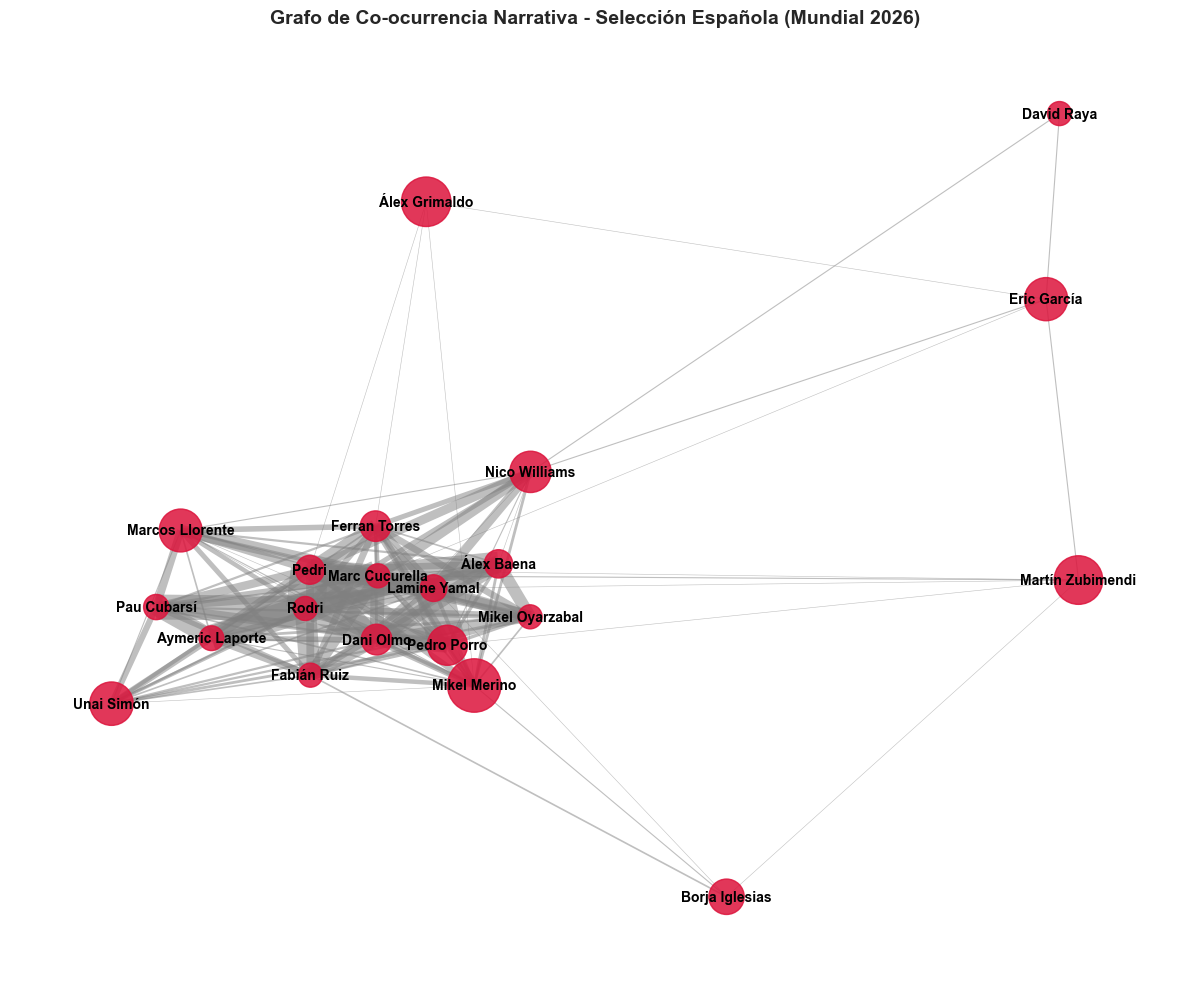


✔ ¡Análisis completado! Grafo exportado en: ..\data\processed\grafo_coocurrencia.png


In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Configuración estilística
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# 1. Carga de datos procesados
processed_dir = os.path.join("..", "data", "processed")
dataset_path = os.path.join(processed_dir, "sentiment_ner_dataset.parquet")

df = pd.read_parquet(dataset_path)

# Explotar la lista de jugadores por segmento para análisis individual
df_exploded = df.explode("players")
df_exploded = df_exploded.dropna(subset=["players"])

# --- A. ANÁLISIS DE SENTIMIENTO ACUMULADO POR JUGADOR ---
print("=== 1. Métricas Emocionales por Jugador ===")
player_stats = df_exploded.groupby("players").agg(
    menciones=("players_count", "count"),
    pos_promedio=("pos_score", "mean"),
    neg_promedio=("neg_score", "mean"),
    polaridad_neta_promedio=("net_polarity", "mean"),
    volatilidad_emocional=("net_polarity", "std")
).reset_index()

# Filtrar jugadores con un mínimo de menciones para evitar sesgos de muestra pequeña
player_stats_filtered = player_stats[player_stats["menciones"] >= 15].sort_values(
    by="polaridad_neta_promedio", ascending=False
)

print(player_stats_filtered.to_string(index=False))

# --- B. CONSTRUCCIÓN DEL GRAFO DE CO-OCURRENCIA GLOBAL ---
print("\n=== 2. Construcción y Métricas de Red (NetworkX) ===")

G = nx.Graph()

# Iterar por segmentos con más de un jugador para agregar aristas
for players_in_seg in df["players"]:
    unique_players = list(set(players_in_seg))
    if len(unique_players) > 1:
        for p1, p2 in combinations(unique_players, 2):
            if G.has_edge(p1, p2):
                G[p1][p2]["weight"] += 1
            else:
                G.add_edge(p1, p2, weight=1)

# Cálculo de Métricas Topológicas
degree_dict = dict(G.degree(weight="weight"))
betweenness_dict = nx.betweenness_centrality(G, weight="weight")
eigenvector_dict = nx.eigenvector_centrality(G, max_iter=1000, weight="weight")

df_network_metrics = pd.DataFrame({
    "Jugador": list(degree_dict.keys()),
    "Grado_Ponderado": list(degree_dict.values()),
    "Betweenness_Centrality": [betweenness_dict[k] for k in degree_dict.keys()],
    "Eigenvector_Centrality": [eigenvector_dict[k] for k in degree_dict.keys()]
}).sort_values(by="Betweenness_Centrality", ascending=False)

print("\n--- Principales Hubs Narrativos de la Selección ---")
print(df_network_metrics.head(10).to_string(index=False))

# --- C. VISUALIZACIÓN DEL GRAFO DE RED ---
plt.figure(figsize=(12, 10))

# Posicionamiento de nodos mediante algoritmo de repulsión de muelles (Fruchterman-Reingold)
pos = nx.spring_layout(G, k=0.5, seed=42)

# Tamaño de nodos proporcional a su Betweenness Centrality
node_sizes = [betweenness_dict[node] * 5000 + 300 for node in G.nodes()]

# Grosor de las aristas proporcional a las apariciones conjuntas
weights = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]

# Dibujar componentes de la red
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="crimson", alpha=0.85)
nx.draw_networkx_edges(G, pos, width=weights, edge_color="gray", alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight="bold")

plt.title("Grafo de Co-ocurrencia Narrativa - Selección Española (Mundial 2026)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()

# Guardar la figura en la carpeta processed
output_graph_path = os.path.join(processed_dir, "grafo_coocurrencia.png")
plt.savefig(output_graph_path, dpi=300)
plt.show()

print(f"\n✔ ¡Análisis completado! Grafo exportado en: {output_graph_path}")

## Interpretación de Resultados: Perfil Emocional y Topología de Red Narrativa

Los resultados obtenidos ofrecen una visión muy reveladora sobre cómo los comentaristas construyen la narrativa de los partidos de la Selección y qué rol juega cada futbolista en el flujo del partido.

---

### 0. Fundamentos del Grafo de Co-ocurrencia $G = (V, E)$

Un **grafo de co-ocurrencia** representa matemáticamente las interacciones o menciones conjuntas entre elementos dentro de una misma ventana de texto (en este caso, los segmentos de transcripción de Whisper):

* **Componentes:** Los **nodos ($V$)** son los futbolistas de la Selección y las **aristas ($E$)** conectan dos jugadores si aparecen nombrados en la misma frase. El **peso ($w_{ij}$)** refleja cuántas veces han coincidido.
* **Métricas Clave:**
  * **Grado Ponderado ($k_i = \sum_{j} w_{ij}$):** Mide el volumen bruto de interacción en la retransmisión.
  * **Centralidad de Intermediación (*Betweenness Centrality*):** Mide la frecuencia con la que un jugador actúa como "puente" en el camino más corto entre otros dos nodos. Puntos altos identifican a conectores entre el núcleo titular y los suplentes/revulsivos.
  * **Centralidad de Autovector (*Eigenvector Centrality*):** Mide la influencia relativa de un jugador basándose en si está conectado con otros nodos altamente transitados e importantes del sistema.
* **Layout Espacial:** La visualización utiliza el algoritmo de muelles (*Fruchterman-Reingold*), donde aristas con mayor peso ejercen más fuerza de atracción, agrupando a los jugadores que combinan con mayor frecuencia.

---

### 1. Análisis del Perfil Emocional por Jugador

Al analizar la polaridad neta promedio ($\bar{S} = \text{POS} - \text{NEG}$) y el número de menciones, observamos tres perfiles claramente diferenciados:

* **Los "Anclajes Positivos" (Nico Williams, Rodri, Fabián Ruiz):**
  * **Rodri (683 menciones, $\bar{S} = +0.054$):** Es el jugador de campo más mencionado dentro del perfil positivo. Al ser el eje de distribución, acumula comentarios de elogio hacia el control, el ritmo y la seguridad en la posesión.
  * **Nico Williams (254 menciones, $\bar{S} = +0.058$):** Mantiene la polaridad neta positiva más alta del equipo. Sus intervenciones suelen estar ligadas a acciones individuales de desborde y regate exitoso, generando picos de optimismo en la locución.

* **Los "Ejes de Tensión y Volumen" (Lamine Yamal, Pedri, Dani Olmo):**
  * **Lamine Yamal (941 menciones, $\bar{S} = -0.111$):** Es el futbolista con mayor volumen absoluto de atención mediática de todo el torneo. Su polaridad neta ligeramente negativa no implica un mal rendimiento, sino su sobreexposición en zonas de alto riesgo: encarar a laterales rivales, faltas recibidas, pérdidas por arriesgar en el regate e interrupciones del juego.
  * **Pedri (643 menciones) y Dani Olmo (534 menciones):** Operan en la mediapunta y zona de creación. Acumulan valores de negatividad derivados de la presión sofocante de las defensas rivales, balones divididos y pases filtrados interceptados.

* **El "Pararrayos del Sufrimiento" (Mikel Merino, Marcos Llorente):**
  * **Marcos Llorente ($\bar{S} = -0.262$) y Mikel Merino ($\bar{S} = -0.242$):** Presentan los índices más bajos de polaridad neta. En la retransmisión, sus nombres suelen aparecer asociados a situaciones de despliegue defensivo, disputas físicas intensas, balones aéreos de tensión o momentos donde España tiene que replegar y "bajar al barro".

---

### 2. Topología de la Red de Co-ocurrencia y Métricas de Centralidad

El análisis del grafo no dirigido $G=(V,E)$ y su visualización nos revelan la estructura de la narrativa colectiva:

* **Núcleo Denso (El "Core" de la Selección):**
  * Se aprecia un clúster central súper denso formado por **Lamine Yamal, Dani Olmo, Pedro Porro, Cucurella, Rodri y Pedri**. La alta concentración de aristas gruesas entre ellos refleja el circuito habitual de elaboración de juego de España.
  * **Eigenvector Centrality:** **Dani Olmo ($0.294$)** y **Pedro Porro ($0.245$)** lideran esta métrica, lo que significa que no solo participan en muchas interacciones (alto grado), sino que están conectados directamente con los focos más activos e influyentes de la narración.

* **Nodos Puerta / "Betweenness Centrality" (Mikel Merino, Álex Grimaldo, Martín Zubimendi):**
  * **Mikel Merino** registra el mayor valor de *Betweenness Centrality* ($0.236$). En la topología del grafo, actúa como el puente conector entre el clúster principal de titulares y los nodos o jugadores más periféricos (como suplentes o revulsivos que entran en segundas partes).
  * Nodos periféricos como **David Raya, Eric García o Borja Iglesias** aparecen aislados o conectados por aristas muy finas, reflejando su rol puntual en momentos específicos del campeonato.